## Libraries

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.model_selection import train_test_split

import torchvision

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

from torchsummary import summary

/tmp/ipython-input-57994026.py:14: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Data

In [3]:
# download dataset
cdata = torchvision.datasets.CIFAR10(root = 'cifar10', download = True)
cdata

100%|██████████| 170M/170M [00:02<00:00, 80.6MB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: cifar10
    Split: Train

In [4]:
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = torch.Tensor(cdata.data)

print('\nOriginal tensor data:')
print(images.shape)

print('\nPermuted data:')
images = images.permute(0,3,1,2)
print(images.shape)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10 classes

Data size:
(50000, 32, 32, 3)

Original tensor data:
torch.Size([50000, 32, 32, 3])

Permuted data:
torch.Size([50000, 3, 32, 32])


# Classification

## Labels

In [17]:
cdata.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [25]:
categories = cdata.classes
labels = cdata.targets

categories

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

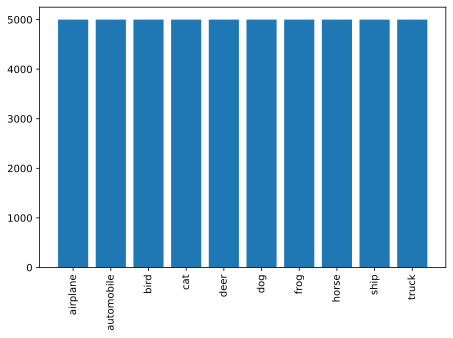

In [39]:
import numpy as np
import matplotlib.pyplot as plt

y = np.asarray(labels)
counts = np.bincount(y, minlength=len(categories))

plt.bar(range(len(categories)), counts)
plt.xticks(range(len(categories)), labels=categories, rotation=90)
plt.tight_layout()
plt.show()

## Norm

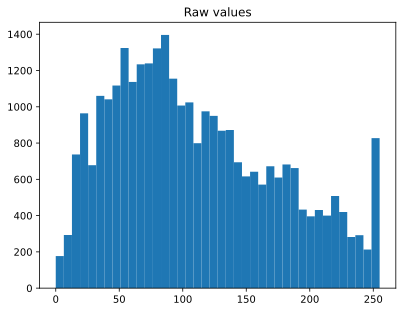

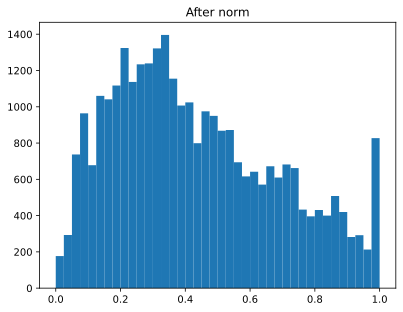

In [40]:
plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('Raw values')
plt.show()

images = images / torch.max(images)

plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('After norm')
plt.show()

## Viz

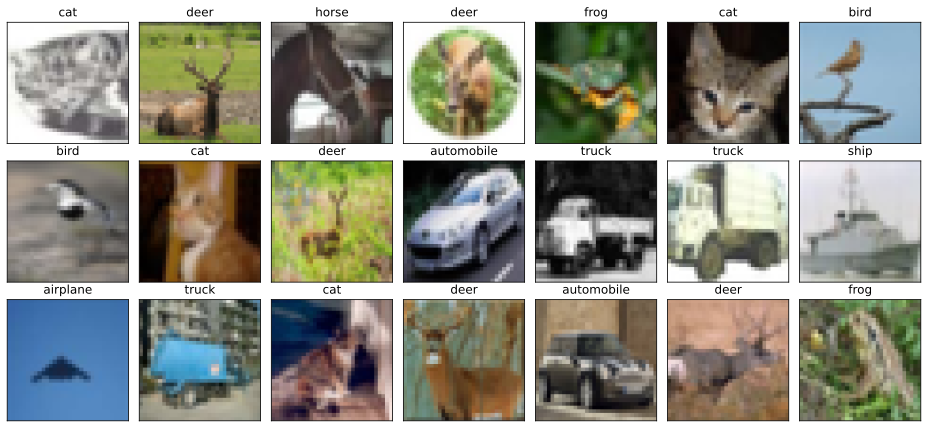

In [49]:
fig, axs = plt.subplots(3, 7, figsize = (13,6))

for i, ax in enumerate(axs.flatten()):

  # pick a random pic
  pic = np.random.randint(images.shape[0])

  I = np.squeeze(images[pic,:,:])
  letter = categories[labels[pic]]

  # viz
  ax.imshow(I.permute(1,2,0), cmap = 'gray')
  ax.set_title('%s'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Loaders

In [55]:
labels = torch.Tensor(labels).long()
images = torch.Tensor(images).float()

In [56]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

In [57]:
# check size (should be images X channels X width X height)
print(train_dataloader.dataset.tensors[0].shape)
print(train_dataloader.dataset.tensors[1].shape)

torch.Size([40000, 3, 32, 32])
torch.Size([40000])


In [58]:
labels.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## Model

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def CreateModel(verbose=False):

  class Net(nn.Module):
    def __init__(self):
      super().__init__()

      def block(cin, cout):
        return nn.Sequential(
          nn.Conv2d(cin, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
          nn.Conv2d(cout, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
        )

      self.b1 = block(3, 64)     # 32x32
      self.b2 = block(64, 128)   # 16x16
      self.b3 = block(128, 256)  # 8x8

      self.pool = nn.MaxPool2d(2)
      self.drop = nn.Dropout(0.3)
      self.gap  = nn.AdaptiveAvgPool2d(1)  # -> (B, C, 1, 1)
      self.fc   = nn.Linear(256, 10)

    def forward(self, x):
      x = self.pool(self.b1(x))
      if verbose: print("b1:", list(x.shape))  # (B,64,16,16)

      x = self.pool(self.b2(x))
      if verbose: print("b2:", list(x.shape))  # (B,128,8,8)

      x = self.pool(self.b3(x))
      if verbose: print("b3:", list(x.shape))  # (B,256,4,4)

      x = self.drop(x)
      x = self.gap(x).squeeze(-1).squeeze(-1)  # (B,256)
      if verbose: print("gap:", list(x.shape))

      x = self.fc(x)
      if verbose: print("out:", list(x.shape))
      return x

  net = Net()
  optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=5e-4)
  loss_fn = nn.CrossEntropyLoss()
  return net, loss_fn, optimizer


In [1]:
import torch
import torch.nn as nn

x = torch.tensor([[[[1.,  2.,  3.,  4.],
                    [5.,  6.,  7.,  8.],
                    [9., 10., 11., 12.],
                    [13.,14.,15.,16.]]]])   # shape: (B=1, C=1, H=4, W=4)

gap = nn.AdaptiveAvgPool2d(1)
y = gap(x)

print(x.shape)  # (1,1,4,4)
print(y.shape)  # (1,1,1,1)
print(y)        # średnia z 1..16 = 8.5


torch.Size([1, 1, 4, 4])
torch.Size([1, 1, 1, 1])
tensor([[[[8.5000]]]])


In [72]:
X, y = next(iter(train_dataloader))
net, loss_fn, optimizer = CreateModel(True)
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

b1: [32, 64, 16, 16]
b2: [32, 128, 8, 8]
b3: [32, 256, 4, 4]
gap: [32, 256]
out: [32, 10]


tensor(2.4854, grad_fn=<NllLossBackward0>)

In [73]:
summary(net, (3, 32, 32))

b1: [2, 64, 16, 16]
b2: [2, 128, 8, 8]
b3: [2, 256, 4, 4]
gap: [2, 256]
out: [2, 10]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,728
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,456
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-

## Train

In [74]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [75]:
def RunModel(epochs, verbose):

  # create a new model
  net, loss_fn, optimizer = CreateModel(verbose)

  net = net.to(device)

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # batch loss and acc
      preds = torch.argmax(y_hat, dim=1)
      batch_accs.append((preds == y).float().mean().item())
      batch_losses.append(loss.item())

    # losses
    train_accs[epoch] = 100 * np.mean(batch_accs)
    train_losses[epoch] = np.mean(batch_losses)

    # test acc
    X, y = next(iter(test_dataloader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad():
      y_hat = net(X)
      loss = loss_fn(y_hat, y)
      preds = torch.argmax(y_hat, dim=1)

    test_losses[epoch] = loss.item()
    test_accs[epoch] = 100 * (preds == y).float().mean().item()


    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [76]:
train_losses, test_losses, train_accs, test_accs, net = RunModel(epochs = 10, verbose = False)

Epoch 0 Train Loss: 1.2114, Test Loss: 0.8809, Train Acc: 56.7375, Test Acc: 69.2100
Epoch 1 Train Loss: 0.8134, Test Loss: 0.6893, Train Acc: 71.3875, Test Acc: 76.2400
Epoch 2 Train Loss: 0.6357, Test Loss: 0.6019, Train Acc: 78.0875, Test Acc: 78.9600
Epoch 3 Train Loss: 0.5314, Test Loss: 0.5115, Train Acc: 81.7075, Test Acc: 82.4200
Epoch 4 Train Loss: 0.4412, Test Loss: 0.5167, Train Acc: 84.8325, Test Acc: 82.4500
Epoch 5 Train Loss: 0.3751, Test Loss: 0.4949, Train Acc: 87.1800, Test Acc: 82.8800
Epoch 6 Train Loss: 0.3103, Test Loss: 0.4742, Train Acc: 89.2400, Test Acc: 83.9600
Epoch 7 Train Loss: 0.2604, Test Loss: 0.4370, Train Acc: 91.0400, Test Acc: 85.5600
Epoch 8 Train Loss: 0.2090, Test Loss: 0.4741, Train Acc: 92.7750, Test Acc: 84.4800
Epoch 9 Train Loss: 0.1741, Test Loss: 0.4880, Train Acc: 94.0675, Test Acc: 84.7100


## Plots

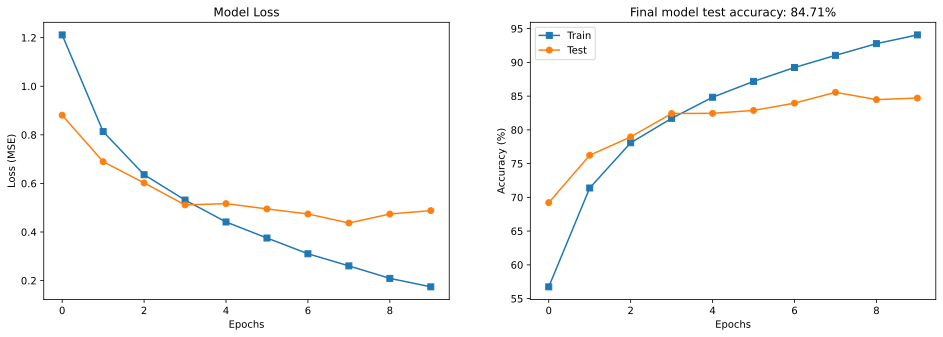

In [77]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses.cpu().detach(), 's-', label = 'Train')
ax[0].plot(test_losses.cpu().detach(), 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs.cpu().detach(), 's-', label = 'Train')
ax[1].plot(test_accs.cpu().detach(), 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

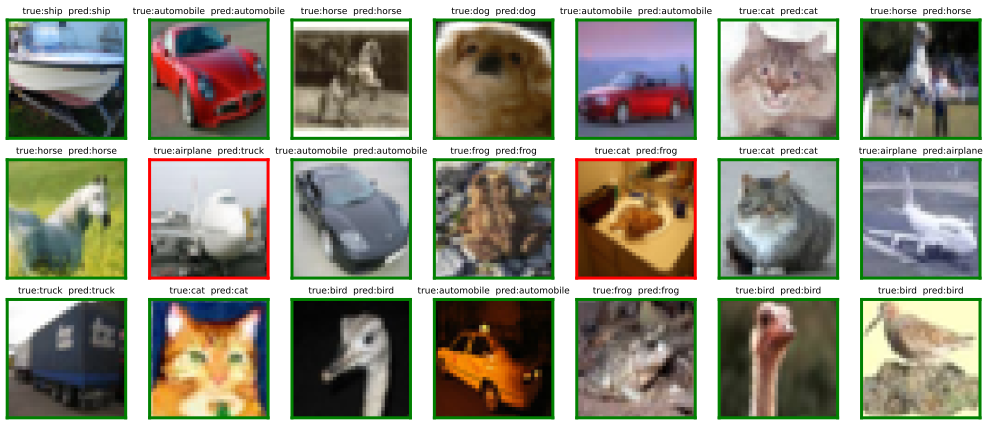

In [79]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def display_preds(net, test_dataloader, class_names=None, device=None, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    xs, ys = [], []
    # zbierz min 21 z test_dataloader
    for xb, yb in test_dataloader:
        xs.append(xb)
        ys.append(yb)
        if sum(t.size(0) for t in xs) >= 21:
            break

    X = torch.cat(xs, dim=0)[:max(21, X.size(0))] if False else torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)

    # wybierz losowe 21 z tego co zebrane
    n = X.size(0)
    idx = np.random.choice(n, 21, replace=False)

    Xs = X[idx]
    Ys = Y[idx]

    with torch.no_grad():
        preds = net(Xs.to(device)).argmax(1).cpu()

    fig, axes = plt.subplots(3, 7, figsize=(14, 6))
    axes = axes.ravel()

    for ax, img, y, p in zip(axes, Xs.cpu(), Ys.cpu(), preds):
        # img: (C,H,W) -> (H,W,C)
        img = img.detach()
        if img.dim() == 3 and img.size(0) in (1,3):
            img_np = img.permute(1,2,0).numpy()
        else:
            img_np = img.numpy()

        # szybkie "żeby było widać" (bez mean/std)
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np.squeeze() if img_np.shape[-1]==1 else img_np)

        yt = int(y); pt = int(p)
        if class_names is not None:
            tname = class_names[yt]
            pname = class_names[pt]
        else:
            tname = str(yt)
            pname = str(pt)

        ax.set_title(f"true:{tname}  pred:{pname}", fontsize=9)

        ok = (yt == pt)
        color = "green" if ok else "red"
        for sp in ax.spines.values():
            sp.set_edgecolor(color)
            sp.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

display_preds(net, test_dataloader, class_names=categories)

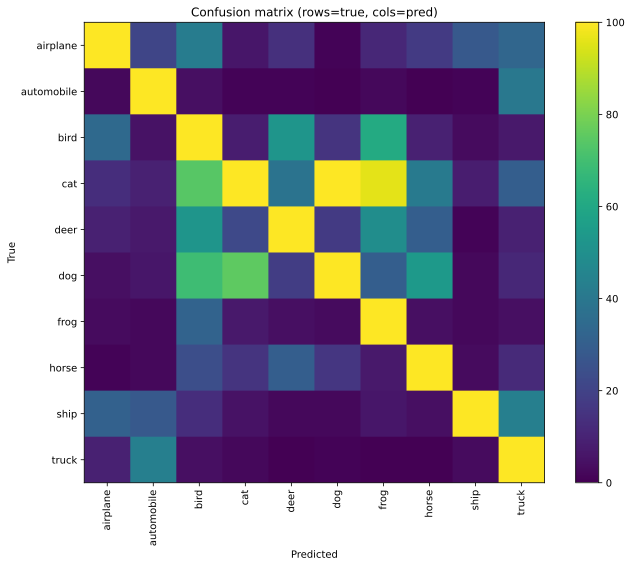

In [86]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_confusion_matrix(net, test_dataloader, categories, device=None):
    if device is None:
        device = next(net.parameters()).device

    net.eval()
    y_true, y_pred = [], []

    for xb, yb in test_dataloader:
        logits = net(xb.to(device))
        pred = logits.argmax(1).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    n = len(categories)
    cm = np.zeros((n, n), dtype=np.int64)  # rows=true, cols=pred
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest",vmax=100)
    plt.title("Confusion matrix (rows=true, cols=pred)")
    plt.colorbar()
    plt.xticks(range(n), categories, rotation=90)
    plt.yticks(range(n), categories)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(net, test_dataloader, categories=categories)

We can tell that most errors come from confusing actual cat with predicted dog or frog.

# CNN Autoencoders

## Model

In [8]:
# create a class for the model
def CreateModel(printtoggle=False):

  class aenet(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()

      # print toggle
      self.print = printtoggle

      ### -------------- encoding layers -------------- ###
      # first convolution layer
      self.encconv1  = nn.Conv2d(3,16,4,padding=1,stride=2) # note: using stride instead of pool to downsample
      # output size: (32+2*1-4)/2 + 1 = 16

      # second convolution layer
      self.encconv2  = nn.Conv2d(16,32,4,padding=1,stride=2)
      # output size: (16+2*1-4)/2 + 1 = 8

      # third convolution layer (latent code layer)
      self.latent  = nn.Conv2d(32,64,4,padding=1,stride=2)
      # output size: (8+2*1-4)/2 + 1 = 4


      ### -------------- decoding layers -------------- ###

      # first convolution layer
      self.decconv1  = nn.ConvTranspose2d(64,32,4,padding=1,stride=2)

      # second convolution layer
      self.decconv2  = nn.ConvTranspose2d(32,16,4,padding=1,stride=2)

      # third convolution layer (output)
      self.output  = nn.ConvTranspose2d(16,3,4,padding=1,stride=2)


    def forward(self,x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first encoder layer
      x = F.leaky_relu( self.encconv1(x) )
      if self.print: print(f'First encoder block: {list(x.shape)}')

      # second encoder layer
      x = F.leaky_relu( self.encconv2(x) )
      if self.print: print(f'Second encoder block: {list(x.shape)}')

      # latent layer
      x = F.leaky_relu( self.latent(x) )
      if self.print: print(f'Third encoder block: {list(x.shape)}')

      # first decoder block
      x = F.leaky_relu( self.decconv1(x) )
      if self.print: print(f'First decoder block: {list(x.shape)}')

      # second decoder block
      x = F.leaky_relu( self.decconv2(x) )
      if self.print: print(f'Second decoder block: {list(x.shape)}')

      # third decoder block (output)
      x = F.leaky_relu( self.output(x) )
      if self.print: print(f'Decoder output: {list(x.shape)}')

      return x

  # create the model instance
  net = aenet(printtoggle)

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001,weight_decay=1e-5)

  return net,lossfun,optimizer


In [9]:
images[:10].shape

torch.Size([10, 3, 32, 32])

In [10]:
net, loss_fn, optimizer = CreateModel()
y_hat = net(images[:10,:,:,:])
loss = loss_fn(y_hat, images[:10])
loss

tensor(16298.6543, grad_fn=<MseLossBackward0>)

In [11]:
summary(net.to(device),(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
            Conv2d-2             [-1, 32, 8, 8]           8,224
            Conv2d-3             [-1, 64, 4, 4]          32,832
   ConvTranspose2d-4             [-1, 32, 8, 8]          32,800
   ConvTranspose2d-5           [-1, 16, 16, 16]           8,208
   ConvTranspose2d-6            [-1, 3, 32, 32]             771
Total params: 83,619
Trainable params: 83,619
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.12
Params size (MB): 0.32
Estimated Total Size (MB): 0.46
----------------------------------------------------------------


## Image after 1 Spin

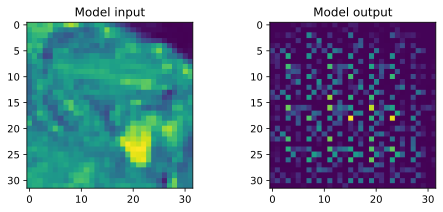

In [12]:
fig, ax = plt.subplots(1,2,figsize = (8,3))
row = np.random.randint(images.shape[0])
img = images[row,:,:,:]
img = img.to(device)
img_hat = net(img)
ax[0].imshow(torch.squeeze(img[0,:,:]).cpu().detach())
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(img_hat[0,:,:]).cpu().detach())
ax[1].set_title('Model output')

plt.show()

## Train

In [13]:
def RunModel(epochs):

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # pick images
    pics_2_use = np.random.choice(images.shape[0], size = 32, replace = False)
    X = images[pics_2_use,:,:,:]

    # forward pass
    y_hat = net(X)
    loss = loss_fn(y_hat, X)
    losses[epoch] = loss.item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%100==0:
      print(f'Epoch: {epoch} | Loss: {loss:.3f}')

  return losses, net

In [17]:
losses, net = RunModel(epochs = 3000)

Epoch: 0 | Loss: 17467.619
Epoch: 100 | Loss: 1363.871
Epoch: 200 | Loss: 1026.207
Epoch: 300 | Loss: 990.264
Epoch: 400 | Loss: 739.514
Epoch: 500 | Loss: 500.729
Epoch: 600 | Loss: 540.564
Epoch: 700 | Loss: 441.875
Epoch: 800 | Loss: 382.107
Epoch: 900 | Loss: 402.644
Epoch: 1000 | Loss: 345.302
Epoch: 1100 | Loss: 421.679
Epoch: 1200 | Loss: 376.462
Epoch: 1300 | Loss: 284.227
Epoch: 1400 | Loss: 321.691
Epoch: 1500 | Loss: 361.662
Epoch: 1600 | Loss: 285.231
Epoch: 1700 | Loss: 399.967
Epoch: 1800 | Loss: 257.037
Epoch: 1900 | Loss: 242.199
Epoch: 2000 | Loss: 228.258
Epoch: 2100 | Loss: 227.521
Epoch: 2200 | Loss: 238.286
Epoch: 2300 | Loss: 213.804
Epoch: 2400 | Loss: 222.813
Epoch: 2500 | Loss: 237.625
Epoch: 2600 | Loss: 187.728
Epoch: 2700 | Loss: 184.883
Epoch: 2800 | Loss: 200.559
Epoch: 2900 | Loss: 212.075


## Plots

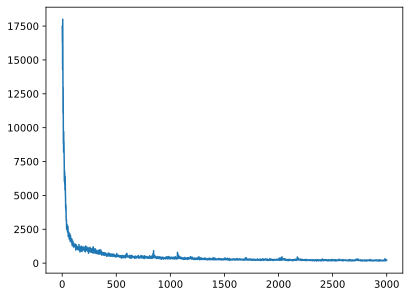

In [18]:
plt.plot(losses)
plt.show()

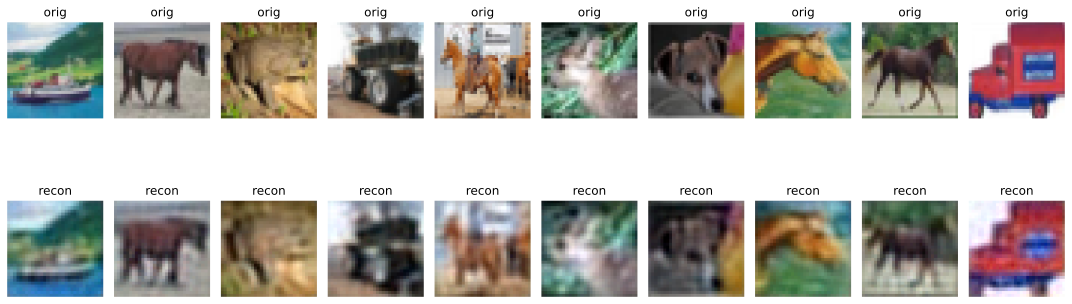

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np

n_samples = 10

net.eval()

idx = np.random.choice(len(images), n_samples, replace=False)
x = images[idx].to(device)

with torch.no_grad():
    x_hat = net(x)

x = x.cpu()
x_hat = x_hat.cpu()

fig, ax = plt.subplots(2, n_samples, figsize=(15, 6))

for i in range(n_samples):
    # oryginał
    ax[0, i].imshow(x[i].permute(1,2,0) / 255.)
    ax[0, i].axis("off")
    ax[0, i].set_title("orig")

    # rekonstrukcja
    ax[1, i].imshow(x_hat[i].permute(1,2,0) / 255.)
    ax[1, i].axis("off")
    ax[1, i].set_title("recon")

plt.tight_layout()
plt.show()